<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/eda-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EDA, Data Preprocessing (Scaling, Encoding, Outliers), Linear/Logistic Regression, Confusion Matrix (Precision, Recall), Model Evaluation, KNN, SVM, Decision Tree, Random Forest va Pipeline

In [79]:
# Google Colab'da Datasetlarni yaratib olish
# import pandas as pd
# import numpy as np

# # Random urug'ini o'rnatamiz (natijalar bir xil chiqishi uchun)
# np.random.seed(42)

# # 1. "uylar_sim.csv" faylini yaratamiz
# n_uylar = 100
# maydon = np.random.randint(30, 150, size=n_uylar).astype(float)
# xonalar = np.random.randint(1, 6, size=n_uylar)
# narx = maydon * 8 + xonalar * 20 + np.random.normal(0, 50, size=n_uylar)
# shahar = np.random.choice(["Toshkent", "Samarqand", "Buxoro"], size=n_uylar)
# maosh = np.random.normal(7000000, 2000000, size=n_uylar)

# # NaN va takroriy qatorlar qo'shamiz
# maydon[np.random.choice(n_uylar, 8, replace=False)] = np.nan
# narx[0] = 1200 # Outlier

# df_uylar = pd.DataFrame({
#     'maydon': maydon,
#     'xonalar_soni': xonalar,
#     'narx': narx,
#     'shahar': shahar,
#     'maosh': maosh
# })
# # Takroriy qatorlar
# df_uylar = pd.concat([df_uylar, df_uylar.iloc[[2, 5, 10]]], ignore_index=True)
# df_uylar.to_csv("uylar_sim.csv", index=False)


# # 2. "kredit_sim.csv" faylini yaratamiz (Klasslar nomutanosib: 90% va 10%)
# n_kredit = 200
# oylik_daromad = np.random.randint(3, 20, size=n_kredit) * 1000000
# yosh = np.random.randint(20, 60, size=n_kredit)
# ish_stazhi = np.random.randint(1, 15, size=n_kredit)
# kredit_summasi = np.random.randint(10, 100, size=n_kredit) * 1000000

# # 90% to'laydi (1), 10% to'lamaydi (0)
# toladimi = np.random.choice([1, 0], size=n_kredit, p=[0.9, 0.1])

# df_kredit = pd.DataFrame({
#     'oylik_daromad': oylik_daromad,
#     'yosh': yosh,
#     'ish_stazhi_yil': ish_stazhi,
#     'kredit_summasi': kredit_summasi,
#     'toladimi': toladimi
# })
# df_kredit.to_csv("kredit_sim.csv", index=False)


# # 3. "dokon_mijozlari_sim.csv" faylini yaratamiz
# n_dokon = 150
# yosh_d = np.random.randint(18, 65, size=n_dokon)
# oylik_xarid = np.random.randint(1, 15, size=n_dokon)
# ortacha_chek = np.random.randint(50, 500, size=n_dokon) * 1000
# sodiqlik = np.random.choice([0, 1], size=n_dokon)
# qaytaradimi = np.random.choice([0, 1], size=n_dokon, p=[0.7, 0.3])

# df_dokon = pd.DataFrame({
#     'yosh': yosh_d,
#     'oylik_xarid_soni': oylik_xarid,
#     'ortacha_chek': ortacha_chek,
#     'sodiqlik_dasturi': sodiqlik,
#     'mahsulot_qaytarish': qaytaradimi
# })
# df_dokon.to_csv("dokon_mijozlari_sim.csv", index=False)

# print("✅ Barcha 3 ta dataset ('uylar_sim.csv', 'kredit_sim.csv', 'dokon_mijozlari_sim.csv') muvaffaqiyatli yaratildi!")

In [80]:
# 1-topshiriq. EDA, Missing values, Duplicates, Outliers
# Fayl: uylar_sim.csv

# uylar_sim.csv faylini o me'moriy df qilib yukla.
# maydon ustunidagi bo'sh (NaN) qiymatlarni median bilan to'ldir.
# Takroriy (duplicated) qatorlarni aniqlab, o me'moriy o'chirib tashla.
# narx ustuni uchun IQR usulida Q1, Q3, IQR, va yuqori/quyi chegaralarni hisobla hamda shu IQR chegarasidan tashqariga chiqqan outlierlarni tozala.

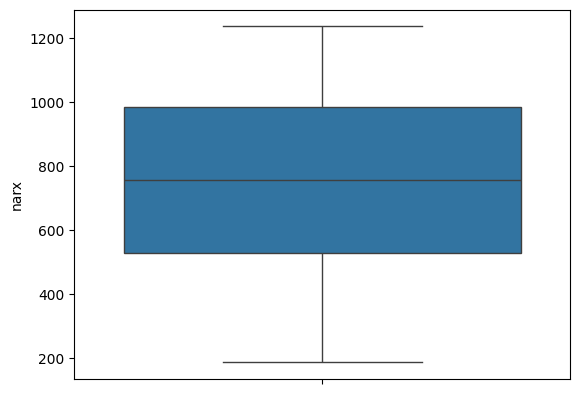

1670.5560941070346
-157.78432441739312


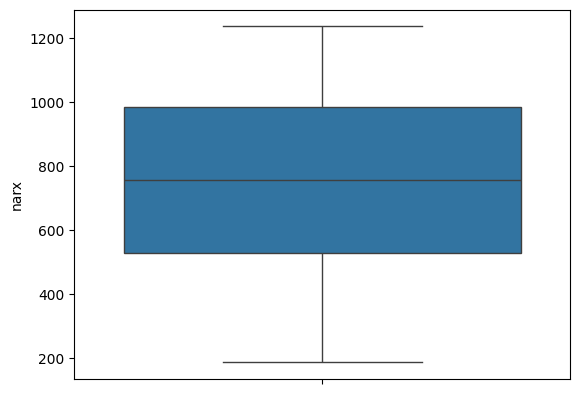

,maydon,xonalar_soni,narx,shahar,maosh
0,132.0,4,1200.000000,Buxoro,7.754593e+06
1,81.0,1,660.676360,Samarqand,1.030270e+07
2,122.0,5,1033.699149,Samarqand,4.346336e+06
3,89.0,5,410.875532,Buxoro,1.068743e+07
4,136.0,2,1182.336351,Samarqand,5.538517e+06
...,...,...,...,...,...
95,73.0,3,603.323945,Toshkent,8.541726e+06
96,63.0,2,428.096588,Toshkent,7.985373e+06
97,89.0,4,890.599082,Toshkent,7.177746e+06
98,91.0,3,842.816489,Toshkent,4.108780e+06


In [81]:
import pandas as pd
uylar_df = pd.read_csv("/content/uylar_sim.csv")
uylar_df.isnull().sum()
maydon_median = uylar_df["maydon"].median()
uylar_df["maydon"] = uylar_df["maydon"].fillna(maydon_median)
uylar_df.isnull().sum()

uylar_df = uylar_df.drop_duplicates()
uylar_df.duplicated().sum()

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    uylar_df["narx"]
)
plt.show()


Q1 = uylar_df["narx"].quantile(0.25)
Q3 = uylar_df["narx"].quantile(0.75)
IQR = Q3-Q1
tepa = Q3 + 1.5 * IQR
past =  Q1 - 1.5 * IQR
print(tepa)
print(past)
uylar_df = uylar_df[(uylar_df["narx"]>=past)&(uylar_df["narx"]<=tepa)]

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    uylar_df["narx"]
)
plt.show()
uylar_df['narx'].describe()
uylar_df

In [82]:
# 2-topshiriq. Preprocessing: Scaling, Encoding va Pipeline tushunchasi
# Fayl: uylar_sim.csv

# maosh ustunini StandardScaler yordamida scale qil.
# shahar ustunini pd.get_dummies (One-Hot Encoding) yordamida o'g'ir va DataFrame'ga birlashtir.
# Imtihoningda xato qilganing: Imtihonda pd.get_dummies(df, columns=["shahar"], dtype=int)
# qilganda muammo chiqishiga sabab — ba'zan stringlar o me'moriy OneHotEncoderga solganda array bo'lib qoladi. Shuni to'g'irlab kodingni yozib ko'r!

In [83]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
scaler = StandardScaler()
uylar_df["maosh"] = scaler.fit_transform(uylar_df[["maosh"]])
uylar_df["maosh"]

# 3. OneHotEncoder (shahar ustuni uchun)
# Encoder yaratamiz (sparse_output=False qilsak, array emas to'g'ridan-to'g'ri matritsa beradi)
encoder = OneHotEncoder(sparse_output=False, dtype=int)
encoded_uylar = encoder.fit_transform(uylar_df[['shahar']])

encoded_df = pd.DataFrame(encoded_uylar, columns=encoder.get_feature_names_out(['shahar']))

# 4. Eski 'shahar' ustunini o'chirib, yangilarini yopishtiramiz
uylar_df = pd.concat([uylar_df.drop('shahar', axis=1), encoded_df], axis=1)

# 5. Natijani tekshiramiz
uylar_df.head()

,maydon,xonalar_soni,narx,maosh,shahar_Buxoro,shahar_Samarqand,shahar_Toshkent
0,132.0,4,1200.000000,0.250479,1,0,0
1,81.0,1,660.676360,1.505162,0,1,0
2,122.0,5,1033.699149,-1.427739,0,1,0
3,89.0,5,410.875532,1.694602,1,0,0
4,136.0,2,1182.336351,-0.840712,0,1,0


In [84]:
# 3-topshiriq. Linear Regression, Evaluation (MSE, R²) va Decision Tree Regressor
# Fayl: uylar_sim.csv

# Features X=[’maydon’,’xonalar_soni’] va Target y=’narx’ ni ajratib ol.
# Ma'lumotlarni 80% train va 20% test qilib bo'l (random_state=42).
# LinearRegression modelini o'qit va test ma'lumotlarida MSE hamda R2 ni hisobla.
# Xuddi shu ma'lumotlarda DecisionTreeRegressor modelini o'qit. Qaysi biri yaxshiroq natija berganini R2 orqali solishtir.

In [85]:
from sklearn.model_selection import train_test_split
X = uylar_df[["maydon","xonalar_soni"]]
y = uylar_df["narx"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LinearRegression

linear = LinearRegression()

linear.fit(X_train,y_train)

from sklearn.metrics import r2_score,mean_squared_error

predict = linear.predict(X_test)

# R2 Modelimiz maqsadli qiymat (y) dagi o'zgarishlarni qanchalik darajada to'g'ri tushuntirib bera olyapti?" degan savolga javob beradi.
r2 = r2_score(y_test,predict)
mse = mean_squared_error(y_test,predict)
print(f"r2: {r2:.2f}")
print(f"mse: {mse:.2f}")

from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train,y_train)

tree_pred = tree.predict(X_test)

tree_r2 = r2_score(y_test,tree_pred)
tree_mse = mean_squared_error(y_test,tree_pred)

print(f"tree r2: {tree_r2}")
print(f"tree mse: {tree_mse}")
# Xulosa linear reg yaxshiroq ishladi

r2: 0.89
mse: 7825.42
tree r2: 0.8537982103244317
tree mse: 10733.473407769261


In [86]:
# 4-topshiriq. Logistic Regression, KNN va Imbalanced Data (Classification)
# Fayl: kredit_sim.csv

# Target toladimi (0 va 1) ustuni.
# LogisticRegression hamda KNeighborsClassifier(n_neighbors=5) modellarini yarat va o'qit.
# Ikkala model uchun confusion_matrix va classification_report (Precision, Recall, F1-Score) ni ekranga chiqar.
# Nazariy savol: Klasslar nomutanosib (10% va 90%) bo'lganda, nega Accuracy bizni aldaydi? Precision va Recall ning farqini 2 ta gapda tushuntir.

# precion model togri db aytganlarida qanchasini togri chiqdi,recall esa togriladan qanchasi togri edi



kredit_df = pd.read_csv("/content/kredit_sim.csv")
print(kredit_df.info())

X = kredit_df[["oylik_daromad","ish_stazhi_yil"]]
y = kredit_df["toladimi"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


logistic = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)
logistic.fit(X_train,y_train)
knn.fit(X_train,y_train)
y_pred_log = logistic.predict(X_test)
y_pred_knn = knn.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report

log_report = classification_report(y_test,y_pred_log)
knn_report = classification_report(y_test,y_pred_knn)

print(f"log report: {log_report}")
print(f"knn report: {knn_report}")

# Xulosa ikkalasi ham bir xilda javob chiqarar ekan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   oylik_daromad   200 non-null    int64
 1   yosh            200 non-null    int64
 2   ish_stazhi_yil  200 non-null    int64
 3   kredit_summasi  200 non-null    int64
 4   toladimi        200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB
None
log report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.93      1.00      0.96        37

    accuracy                           0.93        40
   macro avg       0.46      0.50      0.48        40
weighted avg       0.86      0.93      0.89        40

knn report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.93      1.00      0.96        37

    accuracy                         

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [87]:
# 5-topshiriq. SVM va Kernel Trick (Nazariya va Kod)
# Fayl: kredit_sim.csv

# SVC(kernel='linear', C=1.0) va SVC(kernel='rbf', C=1.0) modellarini sinab ko'r.
# Nazariya: SVM'dagi C giperparametri va Kernel Trick nima uchun kerakligini o'z so'zing bilan qisqa yoz.
# C parametri jazolash uchun a Kernel trick fazga kotarib yol tortish orqali ajratish uchun

from sklearn.svm import SVC


svm_1 = SVC(kernel='linear',C=1.0)
svm_2 = SVC(kernel='rbf',C=1.0)

svm_1.fit(X_train,y_train)
svm_2.fit(X_train,y_train)

y_pred_svm1 = svm_1.predict(X_test)
y_pred_svm2 = svm_2.predict(X_test)

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_svm1))
print("----" * 10)
print(confusion_matrix(y_test, y_pred_svm2))
print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
print(classification_report(y_test, y_pred_svm1))
print("----" * 10)
print(classification_report(y_test, y_pred_svm2))
# Xulosa : svm 2 chisi yaxshiroq topgan cmatrixga va reportga qaraganda,


--- Confusion Matrix ---
[[ 3  0]
 [37  0]]
----------------------------------------
[[ 0  3]
 [ 0 37]]

--- Classification Report (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

           0       0.07      1.00      0.14         3
           1       0.00      0.00      0.00        37

    accuracy                           0.07        40
   macro avg       0.04      0.50      0.07        40
weighted avg       0.01      0.07      0.01        40

----------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.93      1.00      0.96        37

    accuracy                           0.93        40
   macro avg       0.46      0.50      0.48        40
weighted avg       0.86      0.93      0.89        40



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [88]:
# 6-topshiriq. Random Forest, Bagging, Boosting va GridSearchCV (Mini Pipeline)
# Fayl: dokon_mijozlari_sim.csv

# Target: mahsulot_qaytarish.
# RandomForestClassifier va GradientBoostingClassifier (yoki XGBClassifier) modellarini o'qit.
# RandomForestClassifier uchun GridSearchCV ishlatib, n_estimators: [50, 100] va max_depth: [3, 5, None] giperparametrlarini eng yaxshisini top (best_params_).
# Full Pipeline bosqichlarini (EDA → Preprocessing → Model selection → Hyperparameter Tuning → Final Evaluation) tushuntirib ber.

In [89]:
dokon_mijozlari_df = pd.read_csv("/content/dokon_mijozlari_sim.csv")
dokon_mijozlari_df.info()
X = dokon_mijozlari_df[["oylik_xarid_soni","ortacha_chek","sodiqlik_dasturi","yosh"]]
y = dokon_mijozlari_df["mahsulot_qaytarish"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1,stratify=y)

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train,y_train)
gb_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test,y_pred_rf))
print("----"*20)
print(classification_report(y_test,y_pred_gb))
# Xulosa ,GradientBoostingClassifier yaxshiroq topdi

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None]
}

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train,y_train)
print("Eng yaxshi parametrlar:", grid_search.best_params_)
print("Eng yaxshi natija (Score):", grid_search.best_score_)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   yosh                150 non-null    int64
 1   oylik_xarid_soni    150 non-null    int64
 2   ortacha_chek        150 non-null    int64
 3   sodiqlik_dasturi    150 non-null    int64
 4   mahsulot_qaytarish  150 non-null    int64
dtypes: int64(5)
memory usage: 6.0 KB
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        22
           1       0.20      0.12      0.15         8

    accuracy                           0.63        30
   macro avg       0.46      0.47      0.46        30
weighted avg       0.58      0.63      0.60        30

--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.86      0.81        22
           1

In [90]:
rf_model = RandomForestClassifier(n_estimators=50,max_depth=3, random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test,y_pred_rf))
# Xulosa gridsearchdan keyin accurancy f1 da 63 dan 73 ga osdi va precisonda 1lar yani togri topganlari ham osdi,lekn recallda 0 lar ham ancha 82 dan95gacha ostdi va
#  barbr GradientBoostingClassifier yaxshiroq bolib qoldi

              precision    recall  f1-score   support

           0       0.75      0.95      0.84        22
           1       0.50      0.12      0.20         8

    accuracy                           0.73        30
   macro avg       0.62      0.54      0.52        30
weighted avg       0.68      0.73      0.67        30



In [91]:
# Full Pipeline bosqichlarini (EDA → Preprocessing → Model selection → Hyperparameter Tuning → Final Evaluation) tushuntirib ber.
# EDA -> datani oqish,tozalash
# Preprocessing -> Modelni oqitishga berishdan oldin togri formaga solish
# Model selection -> Modelni tanlab oqitish
# Hyperparameter Tuning -> togri parametrlarni tanlab upgrade qilish
# Final Evaluation -> songi resultni korish